In [375]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [376]:
image_path = '/content/Yousuf-Karsh-Albert-Einstein-1948-02-1899x1960.jpg'
img = Image.open(image_path).convert('L')

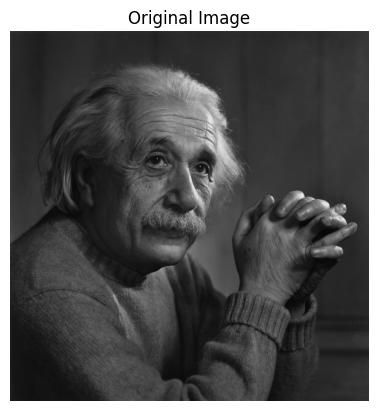

In [377]:
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [378]:
img_array = np.array(img, dtype=float)

In [379]:
img_array

array([[71., 71., 70., ..., 69., 69., 69.],
       [69., 69., 69., ..., 68., 68., 68.],
       [67., 67., 67., ..., 67., 67., 67.],
       ...,
       [43., 42., 41., ..., 59., 59., 59.],
       [43., 42., 41., ..., 60., 60., 60.],
       [43., 42., 41., ..., 60., 60., 60.]])

In [380]:
img_array.shape

(1960, 1899)

In [381]:
hist = np.zeros(256, dtype=float)
for pixel in img_array.flatten():
    hist[int(pixel)] += 1

#cdf = hist.cumsum()

In [382]:
hist

array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 2.0000e+00,
       1.0000e+00, 4.0000e+00, 2.4000e+01, 1.0000e+02, 3.3500e+02,
       1.6060e+03, 2.2750e+03, 4.6100e+03, 5.6210e+03, 7.1780e+03,
       1.1063e+04, 1.3037e+04, 1.5756e+04, 2.1258e+04, 3.1221e+04,
       3.8843e+04, 4.2834e+04, 4.0995e+04, 3.9660e+04, 3.8548e+04,
       3.5027e+04, 3.5259e+04, 3.5530e+04, 3.5513e+04, 3.5698e+04,
       3.6019e+04, 3.8249e+04, 3.7449e+04, 3.8450e+04, 4.0478e+04,
       4.1804e+04, 4.9562e+04, 5.9093e+04, 8.0141e+04, 8.8190e+04,
       8.0653e+04, 8.5050e+04, 9.1353e+04, 9.0756e+04, 8.6227e+04,
       9.2586e+04, 8.2977e+04, 8.0450e+04, 8.5980e+04, 8.4090e+04,
       8.6384e+04, 8.8218e+04, 8.6522e+04, 7.3881e+04, 6.9268e+04,
       6.5482e+04, 6.3108e+04, 6.1944e+04, 4.7726e+04, 3.7567e+04,
       3.1073e+04, 2.8244e+04, 2.8280e+04, 2.9057e+04, 2.9573e

In [383]:
hist.shape

(256,)

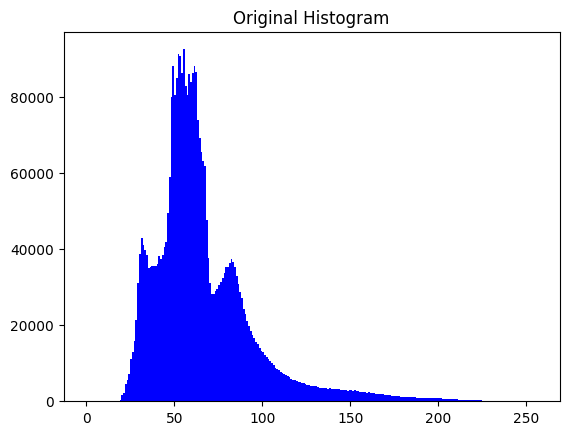

In [384]:
plt.title('Original Histogram')
plt.hist(img_array.flatten(), bins=256, range=[0,256], color='blue')
plt.show()

In [385]:
total_pixels = img_array.shape[0] * img_array.shape[1]
pdf = np.zeros_like(hist, dtype=float)
for i in range(len(hist)):
    pdf[i] = hist[i] / total_pixels
#pdf = hist / total_pixels

In [386]:
cdf = np.zeros_like(hist, dtype=float)

cdf[0] = pdf[0]
for i in range(1, len(pdf)):
    cdf[i] = cdf[i-1] + pdf[i]

In [387]:
cdf

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.68669869e-07, 2.68669869e-07, 8.06009608e-07, 1.07467948e-06,
       2.14935895e-06, 8.59743581e-06, 3.54644227e-05, 1.25468829e-04,
       5.56952639e-04, 1.16817659e-03, 2.40674469e-03, 3.91693802e-03,
       5.84545034e-03, 8.81774511e-03, 1.23203942e-02, 1.65535567e-02,
       2.22649407e-02, 3.06530827e-02, 4.10890264e-02, 5.25972316e-02,
       6.36113529e-02, 7.42667999e-02, 8.46234860e-02, 9.40341856e-02,
       1.03507216e-01, 1.13053057e-01, 1.22594330e-01, 1.32185307e-01,
       1.41862527e-01, 1.52138881e-01, 1.62200299e-01, 1.72530655e-01,
       1.83405874e-01, 1.94637349e-01, 2.07953165e-01, 2.23829674e-01,
       2.45361146e-01, 2.69055142e-01, 2.90724173e-01, 3.13574545e-01,
       3.38118344e-01, 3.62501746e-01, 3.85668343e-01, 4.10543412e-01,
      

In [388]:
# #cdf_normalized = ((cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())).astype(np.uint8)
# denominator = (cdf.max() - cdf.min())
# if denominator == 0:
#     cdf_normalized = cdf
# else:
#     cdf_normalized = ((cdf - cdf.min()) * 255 / denominator).astype(np.uint8)
# equalized_img = cdf_normalized[img_array.astype(np.uint8)]

In [389]:
#cdf = cdf / cdf.max()
#cdf_normalized = np.round(cdf * 255).astype(np.uint8)
#equalized_img = cdf_normalized[img_array.astype(np.uint8)]

In [390]:
cdf_normalized = np.zeros_like(cdf, dtype=float)

for i in range(len(cdf)):
    cdf_normalized[i] = round(cdf[i] * 255)

In [391]:
cdf_normalized.shape

(256,)

In [392]:
equalized_img = np.zeros_like(img_array, dtype=float)

for i in range(img_array.shape[0]):
    for j in range(img_array.shape[1]):
        pixel = img_array[i, j]
        equalized_img[i, j] = cdf_normalized[int(pixel)]

In [393]:
cdf_normalized

array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         1.,   1.,   1.,   2.,   3.,   4.,   6.,   8.,  10.,  13.,  16.,
        19.,  22.,  24.,  26.,  29.,  31.,  34.,  36.,  39.,  41.,  44.,
        47.,  50.,  53.,  57.,  63.,  69.,  74.,  80.,  86.,  92.,  98.,
       105., 110., 116., 122., 128., 133., 139., 145., 150., 155., 160.,
       164., 168., 172., 174., 176., 178., 180., 182., 184., 186., 188.,
       191., 193., 195., 198., 200., 203., 205., 208., 210., 212., 214.,
       216., 218., 219., 221., 222., 223., 224., 226., 227., 228., 229.,
       230., 230., 231., 232., 233., 234., 234., 235., 236., 236., 237.,
       237., 238., 238., 239., 239., 240., 240., 240., 241., 241., 241.,
       242., 242., 242., 243., 243., 243., 244., 244., 244., 244., 245.,
       245., 245., 245., 246., 246., 246., 246., 247., 247., 247., 247.,
       247., 248., 248., 248., 248., 248., 249., 24

In [394]:
equalized_img

array([[178., 178., 176., ..., 174., 174., 174.],
       [174., 174., 174., ..., 172., 172., 172.],
       [168., 168., 168., ..., 168., 168., 168.],
       ...,
       [ 44.,  41.,  39., ..., 128., 128., 128.],
       [ 44.,  41.,  39., ..., 133., 133., 133.],
       [ 44.,  41.,  39., ..., 133., 133., 133.]])

In [395]:
equalized_img.shape

(1960, 1899)

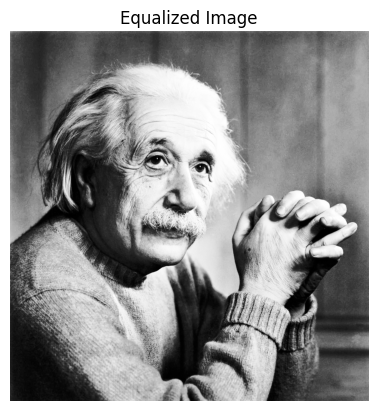

In [396]:
plt.title('Equalized Image')
plt.imshow(equalized_img, cmap='gray')
plt.axis('off')

plt.show()

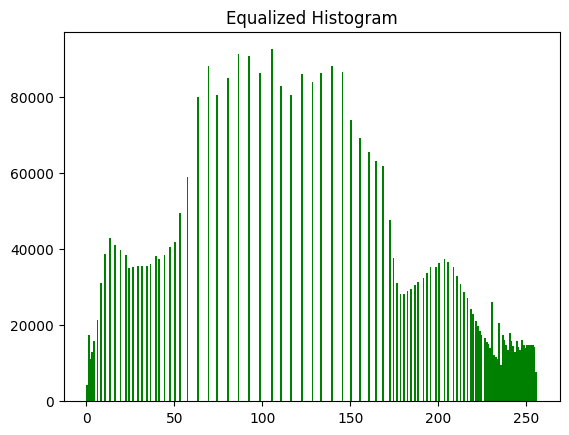

In [397]:
plt.title('Equalized Histogram')
plt.hist(equalized_img.flatten(), bins=256, range=[0,256], color='green')

plt.show()